In [4]:
using DifferentialEquations, BoundaryValueDiffEq, Plots

function theta_profile(H_non_dim)
    L = 50.0

    # 4th-order ODE as first-order system
    function ode!(du, u, p, r)
        theta, dtheta, ddtheta, dddtheta = u
        r_safe = max(r, 1e-6)

        A = -sin(2*theta)
        B = r_safe*(1 + 2*cos(2*theta))*dtheta
        C = r_safe^2*((dtheta^2 - 0.5)*sin(2*theta) - (1 + 2*cos(2*theta))*ddtheta)
        D = r_safe^3*(dtheta - 2*dtheta^3 + 2*dddtheta)
        E = r_safe^4*(H_non_dim*sin(theta) + ddtheta - 6*dtheta^2*ddtheta)

        theta4 = -(A + B + C + D + E)/r_safe^4

        du[1] = dtheta
        du[2] = ddtheta
        du[3] = dddtheta
        du[4] = theta4
    end

    # Boundary conditions
    function bc!(res, ua, ub, p)
        res[1] = ua[1] - pi    # theta(0)
        res[2] = ua[2]         # theta'(0)
        res[3] = ub[1]         # theta(L)
        res[4] = ub[2]         # theta'(L)
    end

    # Initial guess: theta ~ pi*exp(-r), zeros for derivatives
    r_mesh = range(1e-4, L, length=400)
    u_guess = zeros(4, length(r_mesh))
    u_guess[1, :] .= pi .* exp.(-r_mesh)

    # Build BVP problem
    tspan = (r_mesh[1], r_mesh[end])
    bvp_prob = BVProblem(ode!, bc!, u_guess, tspan)

    # Solve
    sol = solve(bvp_prob, MIRK4(), maxiters=10000, reltol=1e-6, abstol=1e-8)

    # Evaluate solution
    r_plot = range(1e-4, L, length=400)
    theta = [sol(r)[1] for r in r_plot]

    # Plot
    plot(r_plot, theta, xlabel="r", ylabel="theta", lw=2, title="Skyrmion profile (Julia BVP)")
    return r_plot, theta
end

# Example usage
r_non_dim, theta_vals = theta_profile(4.3)

ArgumentError: ArgumentError: dt must be positive

In [189]:
qp = sqrt(complex(-1 + sqrt(complex(1-4*Ha))))/sqrt(2)
qm = sqrt(complex(-1 - sqrt(complex(1-4*Ha))))/sqrt(2)
qp, qm

(0.3217971264527913 + 0.7768869870150187im, 0.3217971264527913 - 0.7768869870150187im)

In [190]:
a = 0.001; b = 0.001
c1 = a+b*im; c2 = a-b*im;
u0 = [real(c1*qp^n * exp(-qp*L) + c2*qm^n * exp(-qm*L)) for n=0:3]

r0 = 10^-4
prob = ODEProblem(skyrmion_ode!, u0, (L, r0))
sol = solve(prob, Rodas5(), reltol=1e-6, abstol=1e-8)

θL = sol(r0)[1]

-1.8273866200827675

In [191]:
function shoot(a,b)
    c1 = a+b*im; c2 = a-b*im;
    u0 = [real(c1*qp^n * exp(-qp*L) + c2*qm^n * exp(-qm*L)) for n=0:3]

    r0 = 10^-4
    prob = ODEProblem(skyrmion_ode!, u0, (L, r0))
    sol = solve(prob, Rodas5(), reltol=1e-6, abstol=1e-8)

    θL = sol(r0)

    return θL[1]-pi, θL[2]
end

shoot (generic function with 2 methods)

In [203]:
using DifferentialEquations, BoundaryValueDiffEq, Plots

# Parameters
Ha = 0.5
L = 20.0

# 4th-order ODE written as first-order system
function skyrmion_ode!(du, u, p, r)
    theta, dtheta, ddtheta, dddtheta = u
    r_safe = max(r, 1e-6)

    A = -sin(2*theta)
    B = r_safe*(1 + 2*cos(2*theta))*dtheta
    C = r_safe^2*((dtheta^2 - 0.5)*sin(2*theta) - (1 + 2*cos(2*theta))*ddtheta)
    D = r_safe^3*(dtheta - 2*dtheta^3 + 2*dddtheta)
    E = r_safe^4*(Ha*sin(theta) + ddtheta - 6*dtheta^2*ddtheta)

    theta4 = -(A + B + C + D + E)/r_safe^4

    du[1] = dtheta
    du[2] = ddtheta
    du[3] = dddtheta
    du[4] = theta4
end

# Boundary conditions
function bc!(res, u0, uL, p)
    res[1] = u0[1] - pi      # theta(0) = pi
    res[2] = uL[1]            # theta(L) = 0
    res[3] = u0[2]            # theta'(0) = 0
    res[4] = uL[2]            # optional: theta'(L) = 0
end

# Initial guess at boundaries
u0_guess = [pi, 0.0, -0.1, 0.0]
uL_guess = [0.0, 0.0, 0.0, 0.0]
initial_guess = [u0_guess, uL_guess]

# tspan must be exactly (t0, t1)
tspan = (0.0, L)

# Create BVProblem
bvp_prob = BVProblem(skyrmion_ode!, bc!, initial_guess, tspan)

# Solve BVP with shooting method internally handled by solver
sol = solve(bvp_prob, Shooting(Vern7()), reltol=1e-6, abstol=1e-8)

# Plot
r_vals = range(0.0, L, length=400)
theta_vals = [sol(r)[1] for r in r_vals]

plot(r_vals, theta_vals, xlabel="r", ylabel="theta(r)", lw=2,
     title="Skyrmion profile (BVP solver)")

ErrorException: invalid redefinition of constant Main.initial_guess

In [195]:
shoot(a,b)

(-4.968979273672561, 14517.555165340369)

In [196]:
shoot(-0.002, -0.001)

(0.014919689536642355, -35743.248886599235)

In [197]:
shoot(-0.001, -0.005)

(0.059313622749444406, -37123.410851909575)

In [201]:
using NLsolve

# Define F(x) = [f1, f2]
function F!(Fvec, x)
    a, b = x
    shoot(a,b)
    Fvec[1], Fvec[2] = shoot(a,b)
end

# Initial guess
x0 = [-0.001, -0.001]

# Solve
sol = nlsolve(F!, x0)

println("Zero found at: ", sol.zero)

Zero found at: [-0.011378555846552632, 0.04437726949091467]


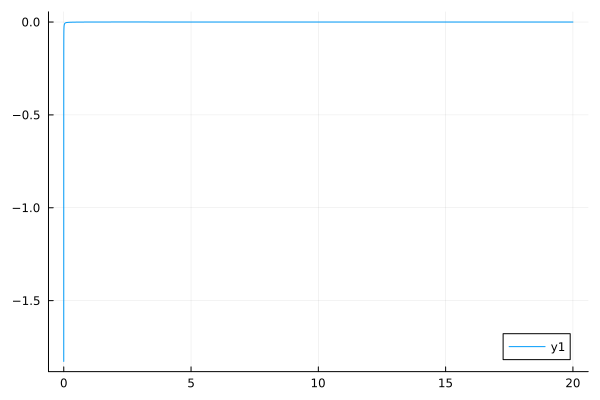

In [200]:
c1 = a+b*im; c2 = a-b*im;
u0 = [real(c1*qp^n * exp(-qp*L) + c2*qm^n * exp(-qm*L)) for n=0:3]

r0 = 10^-4
prob = ODEProblem(skyrmion_ode!, u0, (L, r0))
sol = solve(prob, Rodas5(), reltol=1e-6, abstol=1e-8)
plot(sol.t,[u[1] for u in sol.u])

In [164]:
sol.u[1]

4-element Vector{Float64}:
  9.102100234868427e-5
  0.00018712305692728602
  5.6069756033374124e-5
 -9.622980972474264e-5

In [172]:
sol.u[end]

4-element Vector{Float64}:
    0.00018538075461128437
   -0.0003383787405170126
 8337.56405562336
   -2.8756992536753887e8

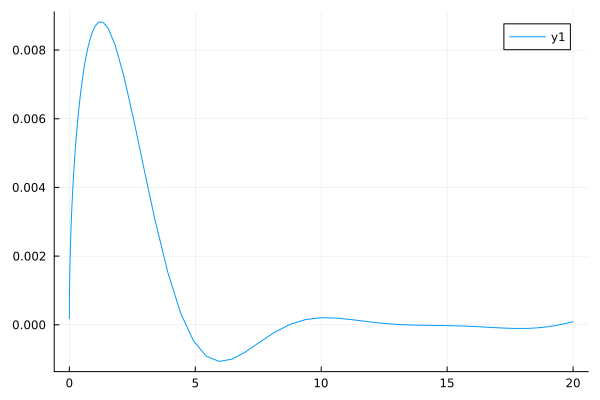

In [166]:
plot(sol.t,[u[1] for u in sol.u])

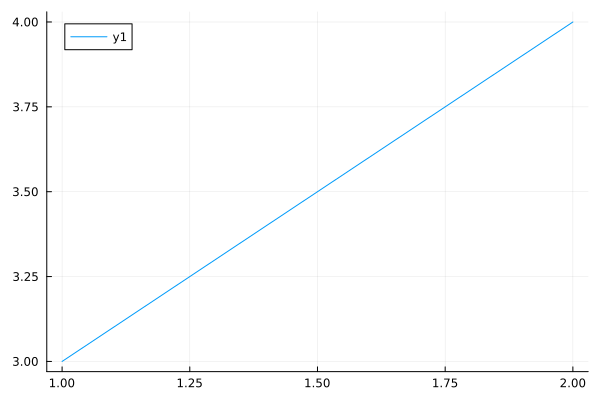

print device already activated


In [153]:
plot([1,2],[3,4])

In [144]:
a, b = sol.zero

2-element Vector{Float64}:
 -0.017246751377420835
  0.06726676471072235

In [121]:
shoot(-0.0008, -0.006)

4-element Vector{Float64}:
      3.3025355019209965
 -40524.03784275921
      1.8325111033139977e9
     -1.600587563664222e14

In [130]:
Pkg.add("LaTeXStrings")

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


```julia
CommonSolve.solve(args...; kwargs...)
```

Solves an equation or other mathematical problem using the algorithm specified in the arguments. Generally, the interface is:

```julia
CommonSolve.solve(prob::ProblemType, alg::SolverType; kwargs...)::SolutionType
```

where the keyword arguments are uniform across all choices of algorithms.

By default, `solve` defaults to using `solve!` on the iterator form, i.e.:

```julia
solve(args...; kwargs...) = solve!(init(args...; kwargs...))
```

```julia
solve(prob::NonlinearProblem, alg::Union{AbstractNonlinearAlgorithm,Nothing}; kwargs...)
```

## Arguments

The only positional argument is `alg` which is optional. By default, `alg = nothing`. If `alg = nothing`, then `solve` dispatches to the NonlinearSolve.jl automated algorithm selection (if `using NonlinearSolve` was done, otherwise it will error with a `MethodError`).

## Keyword Arguments

The NonlinearSolve.jl universe has a large set of common arguments available for the `solve` function. These arguments apply to `solve` on any problem type and are only limited by limitations of the specific implementations.

Many of the defaults depend on the algorithm or the package the algorithm derives from. Not all of the interface is provided by every algorithm. For more detailed information on the defaults and the available options for specific algorithms / packages, see the manual pages for the solvers of specific problems.

#### Error Control

  * `abstol`: Absolute tolerance.
  * `reltol`: Relative tolerance.

These tolerances are interpreted by the termination condition.

### Miscellaneous

  * `maxiters`: Maximum number of iterations before stopping. Defaults to 1e5.
  * `verbose`: Toggles whether warnings are thrown when the solver exits early. Defaults to true.

### Sensitivity Algorithms (`sensealg`)

`sensealg` is used for choosing the way the automatic differentiation is performed. For  more information, see the documentation for [SciMLSensitivity](https://docs.sciml.ai/SciMLSensitivity/stable/)

```julia
solve(prob::AbstractDEProblem, alg::Union{AbstractDEAlgorithm,Nothing}; kwargs...)
```

## Arguments

The only positional argument is `alg` which is optional. By default, `alg = nothing`. If `alg = nothing`, then `solve` dispatches to the DifferentialEquations.jl automated algorithm selection (if `using DifferentialEquations` was done, otherwise it will error with a `MethodError`).

## Keyword Arguments

The DifferentialEquations.jl universe has a large set of common arguments available for the `solve` function. These arguments apply to `solve` on any problem type and are only limited by limitations of the specific implementations.

Many of the defaults depend on the algorithm or the package the algorithm derives from. Not all of the interface is provided by every algorithm. For more detailed information on the defaults and the available options for specific algorithms / packages, see the manual pages for the solvers of specific problems. To see whether a specific package is compatible with the use of a given option, see the [Solver Compatibility Chart](https://docs.sciml.ai/DiffEqDocs/stable/basics/compatibility_chart/#Solver-Compatibility-Chart)

### Default Algorithm Hinting

To help choose the default algorithm, the keyword argument `alg_hints` is provided to `solve`. `alg_hints` is a `Vector{Symbol}` which describe the problem at a high level to the solver. The options are:

  * `:auto` vs `:nonstiff` vs `:stiff` - Denotes the equation as nonstiff/stiff. `:auto` allow the default handling algorithm to choose stiffness detection algorithms. The default handling defaults to using `:auto`.

Currently unused options include:

  * `:interpolant` - Denotes that a high-precision interpolation is important.
  * `:memorybound` - Denotes that the solver will be memory bound.

This functionality is derived via the benchmarks in [SciMLBenchmarks.jl](https://github.com/SciML/SciMLBenchmarks.jl)

#### SDE Specific Alghints

  * `:additive` - Denotes that the underlying SDE has additive noise.
  * `:stratonovich` - Denotes that the solution should adhere to the Stratonovich interpretation.

### Output Control

These arguments control the output behavior of the solvers. It defaults to maximum output to give the best interactive user experience, but can be reduced all the way to only saving the solution at the final timepoint.

The following options are all related to output control. See the "Examples" section at the end of this page for some example usage.

  * `dense`: Denotes whether to save the extra pieces required for dense (continuous) output. Default is `save_everystep && isempty(saveat)` for algorithms which have the ability to produce dense output, i.e. by default it's `true` unless the user has turned off saving on steps or has chosen a `saveat` value. If `dense=false`, the solution still acts like a function, and `sol(t)` is a linear interpolation between the saved time points.
  * `saveat`: Denotes specific times to save the solution at, during the solving phase. The solver will save at each of the timepoints in this array in the most efficient manner available to the solver. If only `saveat` is given, then the arguments `save_everystep` and `dense` are `false` by default. If `saveat` is given a number, then it will automatically expand to `tspan[1]:saveat:tspan[2]`. For methods where interpolation is not possible, `saveat` may be equivalent to `tstops`. The default value is `[]`.
  * `save_idxs`: Denotes the indices for the components of the equation to save. Defaults to saving all indices. For example, if you are solving a 3-dimensional ODE, and given `save_idxs = [1, 3]`, only the first and third components of the solution will be outputted. Notice that of course in this case the outputted solution will be two-dimensional.
  * `tstops`: Denotes *extra* times that the timestepping algorithm must step to. This should be used to help the solver deal with discontinuities and singularities, since stepping exactly at the time of the discontinuity will improve accuracy. If a method cannot change timesteps (fixed timestep multistep methods), then `tstops` will use an interpolation, matching the behavior of `saveat`. If a method cannot change timesteps and also cannot interpolate, then `tstops` must be a multiple of `dt` or else an error will be thrown. `tstops` may also be a function `tstops(p, tspan)`, accepting the parameter object and `tspan`, returning the vector of time points to stop at. Default is `[]`.
  * `d_discontinuities:` Denotes locations of discontinuities in low order derivatives. This will force FSAL algorithms which assume derivative continuity to re-evaluate the derivatives at the point of discontinuity. The default is `[]`.
  * `save_everystep`: Saves the result at every step. Default is true if `isempty(saveat)`.
  * `save_on`: Denotes whether intermediate solutions are saved. This overrides the settings of `dense`, `saveat` and `save_everystep` and is used by some applications to manually turn off saving temporarily. Everyday use of the solvers should leave this unchanged. Defaults to `true`.
  * `save_start`: Denotes whether the initial condition should be included in the solution type as the first timepoint. This setting overrides `saveat` when set to `false`. Defaults to `save_everystep || isempty(saveat) || saveat isa Number || prob.tspan[1] in saveat`.
  * `save_end`: Denotes whether the final condition should be included in the solution type as the final timepoint. This setting is overridden by other saving settings when set to `false`. Defaults to `save_everystep || isempty(saveat) || saveat isa Number || prob.tspan[2] in saveat`.
  * `initialize_save`: Denotes whether to save after the callback initialization phase (when `u_modified=true`). Defaults to `true`.

Note that `dense` requires `save_everystep=true` and `saveat=false`. If you need additional saving while keeping dense output, see [the SavingCallback in the Callback Library](https://docs.sciml.ai/DiffEqCallbacks/stable/output_saving/#DiffEqCallbacks.SavingCallback).

### Stepsize Control

These arguments control the timestepping routines.

#### Basic Stepsize Control

These are the standard options for controlling stepping behavior. Error estimates do the comparison

$$
err_{scaled} = err/(abstol + max(uprev,u)*reltol)
$$

The scaled error is guaranteed to be `<1` for a given local error estimate (note: error estimates are local unless the method specifies otherwise). `abstol` controls the non-scaling error and thus can be thought of as the error around zero. `reltol` scales with the size of the dependent variables and so one can interpret `reltol=1e-3` as roughly being (locally) correct to 3 digits. Note tolerances can be specified element-wise by passing a vector whose size matches `u0`.

  * `adaptive`: Turns on adaptive timestepping for appropriate methods. Default is true.
  * `abstol`: Absolute tolerance in adaptive timestepping. This is the tolerance on local error estimates, not necessarily the global error (though these quantities are related). Defaults to `1e-6` on deterministic equations (ODEs/DDEs/DAEs) and `1e-2` on stochastic equations (SDEs/RODEs).
  * `reltol`: Relative tolerance in adaptive timestepping.  This is the tolerance on local error estimates, not necessarily the global error (though these quantities are related). Defaults to `1e-3` on deterministic equations (ODEs/DDEs/DAEs) and `1e-2` on stochastic equations (SDEs/RODEs).
  * `dt`: Sets the initial stepsize. This is also the stepsize for fixed timestep methods. Defaults to an automatic choice if the method is adaptive.
  * `dtmax`: Maximum dt for adaptive timestepping. Defaults are package-dependent.
  * `dtmin`: Minimum dt for adaptive timestepping. Defaults are package-dependent.
  * `force_dtmin`: Declares whether to continue, forcing the minimum `dt` usage. Default is `false`, which has the solver throw a warning and exit early when encountering the minimum `dt`. Setting this true allows the solver to continue, never letting `dt` go below `dtmin` (and ignoring error tolerances in those cases). Note that `true` is not compatible with most interop packages.

#### Fixed Stepsize Usage

Note that if a method does not have adaptivity, the following rules apply:

  * If `dt` is set, then the algorithm will step with size `dt` each iteration.
  * If `tstops` and `dt` are both set, then the algorithm will step with either a size `dt`, or use a smaller step to hit the `tstops` point.
  * If `tstops` is set without `dt`, then the algorithm will step directly to each value in `tstops`
  * If neither `dt` nor `tstops` are set, the solver will throw an error.

#### [Advanced Adaptive Stepsize Control](https://docs.sciml.ai/DiffEqDocs/stable/extras/timestepping/)

These arguments control more advanced parts of the internals of adaptive timestepping and are mostly used to make it more efficient on specific problems. For detailed explanations of the timestepping algorithms, see the [timestepping descriptions](https://docs.sciml.ai/DiffEqDocs/stable/extras/timestepping/#timestepping)

  * `internalnorm`: The norm function `internalnorm(u,t)` which error estimates are calculated. Required are two dispatches: one dispatch for the state variable and the other on the elements of the state variable (scalar norm). Defaults are package-dependent.
  * `controller`: Possible examples are [`IController`](https://docs.sciml.ai/DiffEqDocs/stable/extras/timestepping/#OrdinaryDiffEq.IController), [`PIController`](https://docs.sciml.ai/DiffEqDocs/stable/extras/timestepping/#OrdinaryDiffEq.PIController), [`PIDController`](https://docs.sciml.ai/DiffEqDocs/stable/extras/timestepping/#OrdinaryDiffEq.PIDController), [`PredictiveController`](https://docs.sciml.ai/DiffEqDocs/stable/extras/timestepping/#OrdinaryDiffEq.PredictiveController). Default is algorithm-dependent.
  * `gamma`: The risk-factor γ in the q equation for adaptive timestepping of the controllers using it. Default is algorithm-dependent.
  * `beta1`: The Lund stabilization α parameter. Default is algorithm-dependent.
  * `beta2`: The Lund stabilization β parameter. Default is algorithm-dependent.
  * `qmax`: Defines the maximum value possible for the adaptive q. Default is algorithm-dependent.
  * `qmin`: Defines the minimum value possible for the adaptive q. Default is algorithm-dependent.
  * `qsteady_min`: Defines the minimum for the range around 1 where the timestep is held constant. Default is algorithm-dependent.
  * `qsteady_max`: Defines the maximum for the range around 1 where the timestep is held constant. Default is algorithm-dependent.
  * `qoldinit`: The initial `qold` in stabilization stepping. Default is algorithm-dependent.
  * `failfactor`: The amount to decrease the timestep by if the Newton iterations of an implicit method fail. Default is 2.

### Memory Optimizations

  * `calck`: Turns on and off the internal ability for intermediate interpolations (also known as intermediate density). Not the same as `dense`, which is post-solution interpolation. This defaults to `dense || !isempty(saveat) ||  "no custom callback is given"`. This can be used to turn off interpolations (to save memory) if one isn't using interpolations when a custom callback is used. Another case where this may be used is to turn on interpolations for usage in the integrator interface even when interpolations are used nowhere else. Note that this is only required if the algorithm doesn't have a free or lazy interpolation (`DP8()`). If `calck = false`, `saveat` cannot be used. The rare keyword `calck` can be useful in event handling.
  * `alias`: an `AbstractAliasSpecifier` object that holds fields specifying which variables to alias when solving. For example, to tell an ODE solver to alias the `u0` array, you can use an `ODEAliases` object,  and the `alias_u0` keyword argument, e.g. `solve(prob,alias = ODEAliases(alias_u0 = true))`.  For more information on what can be aliased for each problem type, see the documentation for the `AbstractAliasSpecifier` associated with that problem type. Set to `true` to alias every variable possible, or to `false` to disable aliasing. Defaults to an `AbstractAliasSpecifier` instance with `nothing` for all fields, which tells the solver to use the default behavior.

### Miscellaneous

  * `maxiters`: Maximum number of iterations before stopping. Defaults to 1e5.
  * `callback`: Specifies a callback. Defaults to a callback function which performs the saving routine. For more information, see the [Event Handling and Callback Functions manual page](https://docs.sciml.ai/DiffEqCallbacks/stable/).
  * `initializealg`: The initialization algorithm for DAEs and ODEs with constraints. Available options include:

      * `DefaultInit()` (default): Automatically chooses the best initialization algorithm
      * `CheckInit()`: Only checks that initial conditions are consistent, errors if not
      * `NoInit()`: Skip initialization completely (for when you know conditions are consistent)
      * `OverrideInit()`: Use problem's initialization_data (typically from ModelingToolkit)
      * `BrownBasicInit()`: Brown's basic initialization algorithm for index-1 DAEs
      * `ShampineCollocationInit()`: Shampine's collocation initialization for general DAEs

    See the [DAE initialization documentation](https://docs.sciml.ai/DiffEqDocs/stable/features/dae_initialization/) for more details.
  * `isoutofdomain`: Specifies a function `isoutofdomain(u,p,t)` where, when it returns true, it will reject the timestep. Disabled by default.
  * `unstable_check`: Specifies a function `unstable_check(dt,u,p,t)` where, when it returns true, it will cause the solver to exit and throw a warning. Defaults to `any(isnan,u)`, i.e. checking if any value is a NaN.
  * `verbose`: Toggles whether warnings are thrown when the solver exits early. Defaults to true.
  * `merge_callbacks`: Toggles whether to merge `prob.callback` with the `solve` keyword argument `callback`. Defaults to `true`.
  * `wrap`: Toggles whether to wrap the solution if `prob.problem_type` has a preferred alternate wrapper type for the solution. Useful when speed, but not shape of solution is important. Defaults to `Val(true)`. `Val(false)` will cancel wrapping the solution.
  * `u0`: The initial condition, overrides the one defined in the problem struct. Defaults to `nothing` (no override, use the `u0` defined in `prob`).
  * `p`: The parameters, overrides the one defined in the problem struct. Defaults to `nothing` (no override, use the `p` defined in `prob`).

### Progress Monitoring

These arguments control the usage of the progressbar in ProgressLogging.jl compatible environments. For information on setting up progress bars in VS Code and other environments, see the [progress bar documentation](https://docs.sciml.ai/DiffEqDocs/stable/features/progress_bar/#Using-Progress-Bars-with-VS-Code).

  * `progress`: Turns on/off the Juno progressbar. Default is false.
  * `progress_steps`: Numbers of steps between updates of the progress bar. Default is 1000.
  * `progress_name`: Controls the name of the progressbar. Default is the name of the problem type.
  * `progress_message`: Controls the message with the progressbar. Defaults to showing `dt`, `t`, the maximum of `u`.
  * `progress_id`: Controls the ID of the progress log message to distinguish simultaneous simulations.

### Error Calculations

If you are using the test problems (ex: `ODETestProblem`), then the following options control the errors which are calculated:

  * `timeseries_errors`: Turns on and off the calculation of errors at the steps which were taken, such as the `l2` error. Default is true.
  * `dense_errors`: Turns on and off the calculation of errors at the steps which require dense output and calculate the error at 100 evenly-spaced points throughout `tspan`. An example is the `L2` error. Default is false.

### Sensitivity Algorithms (`sensealg`)

`sensealg` is used for choosing the way the automatic differentiation is performed. For more information, see the documentation for SciMLSensitivity: https://docs.sciml.ai/SciMLSensitivity/stable/

## Examples

The following lines are examples of how one could use the configuration of `solve()`. For these examples a 3-dimensional ODE problem is assumed, however the extension to other types is straightforward.

1. `solve(prob, AlgorithmName())` : The "default" setting, with a user-specified algorithm (given by `AlgorithmName()`). All parameters get their default values. This means that the solution is saved at the steps the Algorithm stops internally and dense output is enabled if the chosen algorithm allows for it.

    All other integration parameters (e.g. stepsize) are chosen automatically.
2. `solve(prob, saveat = 0.01, abstol = 1e-9, reltol = 1e-9)` : Standard setting for accurate output at specified (and equidistant) time intervals, used for e.g. Fourier Transform. The solution is given every 0.01 time units, starting from `tspan[1]`. The solver used is `Tsit5()` since no keyword `alg_hints` is given.
3. `solve(prob, maxiters = 1e7, progress = true, save_idxs = [1])` : Using longer maximum number of solver iterations can be useful when a given `tspan` is very long. This example only saves the first of the variables of the system, either to save size or because the user does not care about the others. Finally, with `progress = true` you are enabling the progress bar.

```julia
solve(prob::IntegralProblem, alg::SciMLBase.AbstractIntegralAlgorithm; kwargs...)
```

## Keyword Arguments

The arguments to `solve` are common across all of the quadrature methods. These common arguments are:

  * `maxiters` (the maximum number of iterations)
  * `abstol` (absolute tolerance in changes of the objective value)
  * `reltol` (relative tolerance  in changes of the objective value)
  * `verbose` (verbosity control via [`IntegralVerbosity`](@ref); defaults to `IntegralVerbosity()`)

```julia
solve(prob::SampledIntegralProblem, alg::SciMLBase.AbstractIntegralAlgorithm; kwargs...)
```

## Keyword Arguments

There are no keyword arguments used to solve `SampledIntegralProblem`s

```julia
solve(prob::OptimizationProblem, alg::AbstractOptimizationAlgorithm,
    args...; kwargs...)::OptimizationSolution
```

For information about the returned solution object, refer to the documentation for [`OptimizationSolution`](@ref)

## Keyword Arguments

The arguments to `solve` are common across all of the optimizers. These common arguments are:

  * `maxiters`: the maximum number of iterations
  * `maxtime`: the maximum amount of time (typically in seconds) the optimization runs for
  * `abstol`: absolute tolerance in changes of the objective value
  * `reltol`: relative tolerance  in changes of the objective value
  * `callback`: a callback function

Some optimizer algorithms have special keyword arguments documented in the solver portion of the documentation and their respective documentation. These arguments can be passed as `kwargs...` to `solve`. Similarly, the special keyword arguments for the `local_method` of a global optimizer are passed as a `NamedTuple` to `local_options`.

Over time, we hope to cover more of these keyword arguments under the common interface.

A warning will be shown if a common argument is not implemented for an optimizer.

## Callback Functions

The callback function `callback` is a function that is called after every optimizer step. Its signature is:

```julia
callback = (state, loss_val) -> false
```

where `state` is an `OptimizationState` and stores information for the current iteration of the solver and `loss_val` is loss/objective value. For more information about the fields of the `state` look at the `OptimizationState` documentation. The callback should return a Boolean value, and the default should be `false`, so the optimization stops if it returns `true`.

### Callback Example

Here we show an example of a callback function that plots the prediction at the current value of the optimization variables. For a visualization callback, we would need the prediction at the current parameters i.e. the solution of the `ODEProblem` `prob`. So we call the `predict` function within the callback again.

```julia
function predict(u)
    Array(solve(prob, Tsit5(), p = u))
end

function loss(u, p)
    pred = predict(u)
    sum(abs2, batch .- pred)
end

callback = function (state, l; doplot = false) #callback function to observe training
    display(l)
    # plot current prediction against data
    if doplot
        pred = predict(state.u)
        pl = scatter(t, ode_data[1, :], label = "data")
        scatter!(pl, t, pred[1, :], label = "prediction")
        display(plot(pl))
    end
    return false
end
```

If the chosen method is a global optimizer that employs a local optimization method, a similar set of common local optimizer arguments exists. Look at `MLSL` or `AUGLAG` from NLopt for an example. The common local optimizer arguments are:

  * `local_method`: optimizer used for local optimization in global method
  * `local_maxiters`: the maximum number of iterations
  * `local_maxtime`: the maximum amount of time (in seconds) the optimization runs for
  * `local_abstol`: absolute tolerance in changes of the objective value
  * `local_reltol`: relative tolerance  in changes of the objective value
  * `local_options`: `NamedTuple` of keyword arguments for local optimizer

```
solve(fx::ZeroProblem, args...; verbose=false, kwargs...)
```

Disptaches to `solve!(init(fx, args...; kwargs...))`. See [`solve!`](@ref) for details.


In [124]:
@doc find_zero

```
find_zero(f, x0, M, [N::AbstractBracketingMethod], [p=nothing]; kwargs...)
```

Interface to one of several methods for finding zeros of a univariate function, e.g. solving $f(x)=0$.

# Arguments

## Positional arguments

  * `f`: the function (univariate or `f(x,p)` with `p` holding parameters)
  * `x0`: the initial condition (a value, initial values, or bracketing interval)
  * `M`: some `AbstractUnivariateZeroMethod` specifying the solver
  * `N`: some bracketing method, when specified creates a hybrid method
  * `p`: for specifying a parameter to `f`. Also can be a keyword, but a positional argument is helpful with broadcasting.

## Keyword arguments

  * `xatol`, `xrtol`: absolute and relative tolerance to decide if `xₙ₊₁ ≈ xₙ`
  * `atol`, `rtol`: absolute and relative tolerance to decide if `f(xₙ) ≈ 0`
  * `maxiters`: specify the maximum number of iterations the algorithm can take.
  * `verbose::Bool`: specifies if details about algorithm should be shown
  * `tracks`: allows specification of `Tracks` objects

# Extended help

# Initial starting value

For most methods, `x0` is a scalar value indicating the initial value in the iterative procedure. (Secant methods can have a tuple specify their initial values.) Values must be a subtype of `Number` and have methods for `float`, `real`, and `oneunit` defined.

For bracketing intervals, `x0` is specified using a tuple, a vector, or any iterable with `extrema` defined. A bracketing interval, $[a,b]$, is one where $f(a)$ and $f(b)$ have different signs.

# Return value

If the algorithm succeeds, the approximate root identified is returned. A `ConvergenceFailed` error is thrown if the algorithm fails. The alternate form `solve(ZeroProblem(f,x0), M)` returns `NaN` in case of failure.

# Specifying a method

A method is specified to indicate which algorithm to employ:

  * There are methods where a bracket is specified: [`Bisection`](@ref), [`A42`](@ref), [`AlefeldPotraShi`](@ref), [`Roots.Brent`](@ref), among others. Bisection is the default for basic floating point types, but `A42` generally requires far fewer iterations.
  * There are several derivative-free methods: cf. [`Order0`](@ref), [`Order1`](@ref) (also [`Roots.Secant`](@ref)), [`Order2`](@ref) (also [`Steffensen`](@ref)), [`Order5`](@ref), [`Order8`](@ref), and [`Order16`](@ref), where the number indicates the order of the convergence.
  * There are some classical methods where derivatives need specification: [`Roots.Newton`](@ref), [`Roots.Halley`](@ref), [`Roots.Schroder`](@ref), among others.
  * Methods intended for problems with multiplicities include [`Roots.Order1B`](@ref), [`Roots.Order2B`](@ref), and `Roots.ThukralXB` for different `X`s.
  * The family [`Roots.LithBoonkkampIJzerman{S,D}`](@ref) ,for different `S` and `D`, uses a linear multistep method root finder. The `(2,0)` method is the secant method, `(1,1)` is Newton's method.

For more detail, see the help page for each method (e.g., `?Order1`). Non-exported methods must be qualified with the module name, as in `?Roots.Schroder`.

If no method is specified, the default method depends on `x0`:

  * If `x0` is a scalar, the default is the more robust `Order0` method.
  * If `x0` is a tuple, vector, or iterable with `extrema` defined indicating a *bracketing* interval, then the `Bisection` method is used for `Float64`, `Float32` or `Float16` types; otherwise the `A42` method is used.

The default methods are chosen to be robust; they may not be as efficient as some others.

# Specifying the function

The function(s) are passed as the first argument.

For the few methods that use one or more derivatives (`Newton`, `Halley`, `Schroder`, `LithBoonkkampIJzerman(S,D)`, etc.) a tuple of functions is used. For the classical algorithms, a function returning `(f(x), f(x)/f'(x), [f'(x)/f''(x)])` may be used.

# Optional arguments (tolerances, limit evaluations, tracing)

  * `xatol` - absolute tolerance for `x` values.
  * `xrtol` - relative tolerance for `x` values.
  * `atol`  - absolute tolerance for `f(x)` values.
  * `rtol`  - relative tolerance for `f(x)` values.
  * `maxiters`   - limit on maximum number of iterations.
  * `strict` - if `false` (the default), when the algorithm stops, possible zeros are checked with a relaxed tolerance.
  * `verbose` - if `true` a trace of the algorithm will be shown on successful completion. See the internal [`Roots.Tracks`](@ref) object to save this trace.

See the help string for `Roots.assess_convergence` for details on convergence. See the help page for `Roots.default_tolerances(method)` for details on the default tolerances.

In general, with floating point numbers, convergence must be understood as not an absolute statement. Even if mathematically `α` is an answer and `xstar` the floating point realization, it may be that `f(xstar) - f(α)  ≈ xstar ⋅  f'(α) ⋅ eps(α)`, so the role of tolerances must be appreciated, and at times specified.

For the `Bisection` methods, convergence is guaranteed over `Float64` values, so the tolerances are set to be $0$ by default.

If a bracketing method is passed in after the method specification, then whenever a bracket is identified during the algorithm, the method will switch to the bracketing method to identify the zero. (Bracketing methods are mathematically guaranteed to converge, non-bracketing methods may or may not converge.)  This is what `Order0` does by default, with an initial secant method switching to the `AlefeldPotraShi` method should a bracket be encountered.

Note: The order of the method is hinted at in the naming scheme. A scheme is order `r` if, with `eᵢ = xᵢ - α`, `eᵢ₊₁ = C⋅eᵢʳ`. If the error `eᵢ` is small enough, then essentially the error will gain `r` times as many leading zeros each step. However, if the error is not small, this will not be the case. Without good initial guesses, a high order method may still converge slowly, if at all. The `OrderN` methods have some heuristics employed to ensure a wider range for convergence at the cost of not faithfully implementing the method, though those are available through unexported methods.

# Examples:

Default methods.

```jldoctest find_zero
julia> using Roots

julia> find_zero(sin, 3)  # use Order0()
3.141592653589793

julia> find_zero(sin, (3,4)) # use Bisection()
3.141592653589793
```

Specifying a method,

```jldoctest find_zero
julia> find_zero(sin, (3,4), Order1())            # can specify two starting points for secant method
3.141592653589793

julia> find_zero(sin, 3.0, Order2())              # Use Steffensen method
3.1415926535897936

julia> find_zero(sin, big(3.0), Order16())        # rapid convergence
3.141592653589793238462643383279502884197169399375105820974944592307816406286198

julia> find_zero(sin, (3, 4), A42())              # fewer function calls than Bisection(), in this case
3.141592653589793

julia> find_zero(sin, (3, 4), FalsePosition(8))   # 1 of 12 possible algorithms for false position
3.141592653589793

julia> find_zero((sin,cos), 3.0, Roots.Newton())  # use Newton's method
3.141592653589793

julia> find_zero((sin, cos, x->-sin(x)), 3.0, Roots.Halley())  # use Halley's method
3.141592653589793
```

Changing tolerances.

```jldoctest find_zero
julia> fn = x -> (2x*cos(x) + x^2 - 3)^10/(x^2 + 1);

julia> x0, xstar = 3.0,  2.9947567209477;

julia> fn(find_zero(fn, x0, Order2())) <= 1e-14  # f(xₙ) ≈ 0, but Δxₙ can be largish
true

julia> find_zero(fn, x0, Order2(), atol=0.0, rtol=0.0) # error: x_n ≉ x_{n-1}; just f(x_n) ≈ 0
ERROR: Roots.ConvergenceFailed("Algorithm failed to converge")
[...]

julia> fn = x -> (sin(x)*cos(x) - x^3 + 1)^9;

julia> x0, xstar = 1.0,  1.112243913023029;

julia> isapprox(find_zero(fn, x0, Order2()), xstar; atol=1e-4)
true

julia> find_zero(fn, x0, Order2(), maxiters=3)    # need more steps to converge
ERROR: Roots.ConvergenceFailed("Algorithm failed to converge")
[...]
```

# Tracing

Passing `verbose=true` will show details on the steps of the algorithm. The `tracks` argument allows the passing of a [`Roots.Tracks`](@ref) object to record the values of `x` and `f(x)` used in the algorithm.

!!! note
    See [`solve!`](@ref) and [`ZeroProblem`](@ref) for an alternate interface.



In [115]:
qp = sqrt(complex(-1 + sqrt(complex(1-4*Ha))))/sqrt(2)
qm = sqrt(complex(-1 - sqrt(complex(1-4*Ha))))/sqrt(2)
qp, qm

(0.3217971264527913 + 0.7768869870150187im, 0.3217971264527913 - 0.7768869870150187im)

In [14]:
Pkg.add("Roots")

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
